In [1]:
%pip install -q --upgrade -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import Atividade_Dark_Patterns.ler_Arquivo as ler
import Atividade_Dark_Patterns.Gemini_Atv as gemini
import Atividade_Dark_Patterns.Openai_Atv as openai

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# 1. Alocando os valores nas respectivas variáveis
listaGemini = ler.ler_arquivo_xlsx(r'/workspaces/Dark_Patterns_Atv/Data_resultados/gemini_manipulative_design.xlsx')
listaOpenai = ler.ler_arquivo_xlsx(r'/workspaces/Dark_Patterns_Atv/Data_resultados/openai_manipulative_design.xlsx')

print("Dark patterns da IA do Gemini:")
display(listaGemini)

print("Dark patterns da IA do Openai:")
display(listaOpenai)

Dark patterns da IA do Gemini:


[{'url': 'https://www.temu.com/',
  'manipulative_design': True,
  'patterns_detected': '[{\'name\': \'Extensive Tracking and Personalization\', \'description\': "The configuration includes a large list of \'optOutFields\' (e.g., gclid, fbclid, ttclid, msclkid) and defines tracking-related cookies (_ttc with ad sub-types). This indicates a significant infrastructure for collecting user data, potentially for highly targeted advertising and personalization. While consent mechanisms are not visible here, extensive, often opaque, data collection can be a manipulative practice."}, {\'name\': \'Urgency and Scarcity Tactics (Implied)\', \'description\': "Numerous localStorage keys (e.g., \'mobile.bg.newbie.lowPriceItem.stressCountDownFirstStage\', \'DAILY_GIFT_RETAIN_POPUP_FREQUENCY_LIMIT_KEY\', \'ATTENDANCE_GIFT_BOX\') suggest the implementation of countdowns, limited-time offers, and promotional pop-ups designed to create a sense of urgency or scarcity to pressure users into making immediat

Dark patterns da IA do Openai:


[{'url': 'https://www.trello.com/',
  'manipulative_design': False,
  'patterns_detected': '[]',
  'security_risks': "['Erro API OpenAI: 429']",
  'confidence_level': 'baixa'},
 {'url': 'https://www.youtube.com/',
  'manipulative_design': False,
  'patterns_detected': '[]',
  'security_risks': "['Erro API OpenAI: 429']",
  'confidence_level': 'baixa'}]

In [6]:
# 2. Transformando em DataFrames para o gráfico
df_Gemini = pd.DataFrame(listaGemini)[['manipulative_design', 'url']].assign(Fonte = 'Gemini')
df_Openai = pd.DataFrame(listaOpenai)[['manipulative_design', 'url']].assign(Fonte = 'Openai')

In [7]:
print(f"Gemini: \n{df_Gemini['manipulative_design'].value_counts()} \n")
print(f"Openai: \n{df_Openai['manipulative_design'].value_counts()}")

Gemini: 
manipulative_design
False    3
True     1
Name: count, dtype: int64 

Openai: 
manipulative_design
False    2
Name: count, dtype: int64


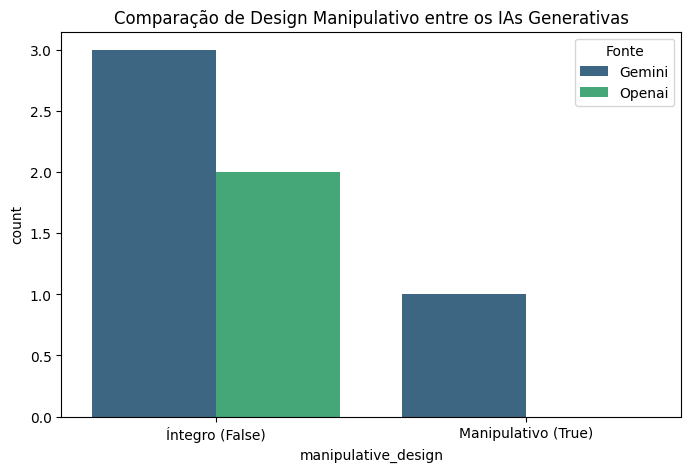

In [8]:
# 3. Criando o gráfico comparativo
df_final = pd.concat([df_Gemini, df_Openai])

plt.figure(figsize=(8, 5))
sns.countplot(data = df_final, x = 'manipulative_design', hue = 'Fonte', palette = 'viridis')

plt.title("Comparação de Design Manipulativo entre os IAs Generativas")
plt.xticks([0, 1], ['Íntegro (False)', 'Manipulativo (True)'])
plt.show()

In [ ]:
df_Resultados = pd.read_excel(r"/workspaces/Dark_Buster_Atv_Patterns/Data/Resultados_esperados.xlsx")
df_Resultados.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   url                           27 non-null     str  
 1   manipulative_design_Buscados  27 non-null     bool 
dtypes: bool(1), str(1)
memory usage: 375.0 bytes


In [ ]:
df_Gemini = df_Gemini.merge(df_Resultados, on='url', how='left')
df_Openai = df_Openai.merge(df_Resultados, on='url', how='left')

In [ ]:
mask_validos_Gemini = df_Gemini['manipulative_design'].notna() & df_Gemini['manipulative_design_Buscados'].notna()

acertos_Gemini = (df_Gemini.loc[mask_validos_Gemini, 'manipulative_design'] == df_Gemini.loc[mask_validos_Gemini, 
                                                                                             'manipulative_design_Buscados']).sum()
total_Gemini = mask_validos_Gemini.sum()

proporcao_Gemini = acertos_Gemini / total_Gemini
percentual_Gemini = proporcao_Gemini * 100

if pd.isna(percentual_Gemini):
    percentual_Gemini = 0

print(f"Quantidade de acertos do Gemini {acertos_Gemini}")
print(f"Percentual de acertos do Gemini {percentual_Gemini}")

Quantidade de acertos do Gemini 1
Percentual de acertos do Gemini 100.0


In [ ]:
erros_Gemini = total_Gemini - acertos_Gemini

labels_Gemini = ['Acertos', 'Erros']
valores_Gemini = [acertos_Gemini, erros_Gemini]

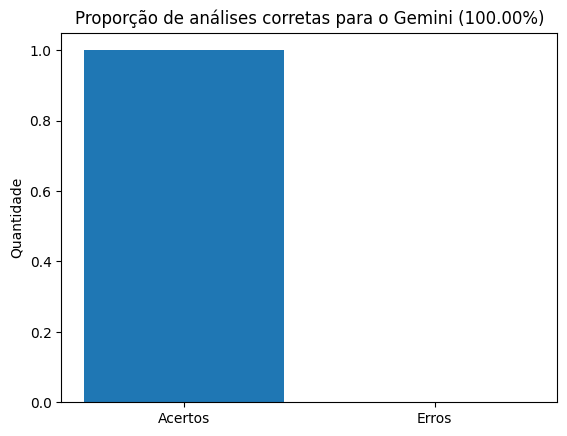

In [ ]:
plt.bar(labels_Gemini, valores_Gemini)
plt.title(f'Proporção de análises corretas para o Gemini ({percentual_Gemini:.2f}%)')
plt.ylabel('Quantidade')
plt.show()

In [ ]:
mask_validos_Openai = df_Openai['manipulative_design'].notna() & df_Openai['manipulative_design_Buscados'].notna()

acertos_Openai = (df_Openai.loc[mask_validos_Openai, 'manipulative_design'] == df_Openai.loc[mask_validos_Openai, 
                                                                                             'manipulative_design_Buscados']).sum()
total_Openai = mask_validos_Openai.sum()

proporcao_Openai = acertos_Openai / total_Openai
percentual_Openai = proporcao_Openai * 100

if pd.isna(percentual_Openai):
    percentual_Openai = 0

print(f"Quantidade de acertos do Openai {acertos_Openai}")
print(f"Percentual de acertos do Openai {percentual_Openai}")

Quantidade de acertos do Openai 0
Percentual de acertos do Openai 0


/tmp/ipykernel_5926/3962617796.py:7: RuntimeWarning: invalid value encountered in scalar divide
  proporcao_Openai = acertos_Openai / total_Openai


In [ ]:
erros_Openai = total_Openai - acertos_Openai

labels_Openai = ['Acertos', 'Erros']
valores_Openai = [acertos_Openai, erros_Gemini]

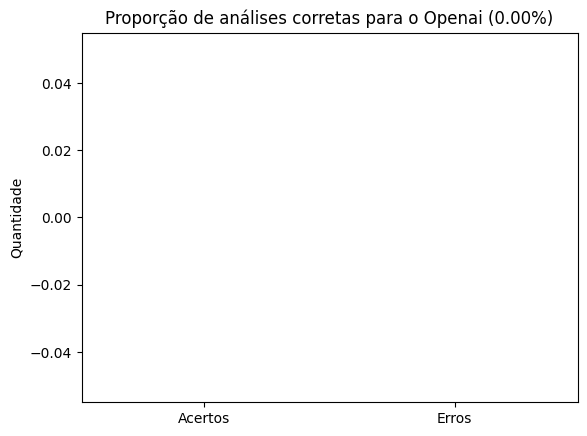

In [ ]:
plt.bar(labels_Openai, valores_Openai)
plt.title(f'Proporção de análises corretas para o Openai ({percentual_Openai:.2f}%)')
plt.ylabel('Quantidade')
plt.show()